In [ ]:
!pip install -q rank_bm25

In [ ]:
import os
import numpy as np
import pandas as pd

from rank_bm25 import BM25Okapi
from tqdm import tqdm

tqdm.pandas()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/FIFI_Research/data"

train_df = pd.read_csv(
    os.path.join(DATA_PATH, "train.tsv"),
    sep="\t"
)

val_df = pd.read_csv(
    os.path.join(DATA_PATH, "val.tsv"),
    sep="\t"
)

In [ ]:
candidate_titles = (
    train_df["original_title"]
    .drop_duplicates()
    .tolist()
)

print("Unique Candidate Titles:", len(candidate_titles))

Unique Candidate Titles: 9999


In [ ]:
tokenized_corpus = [
    title.lower().split()
    for title in candidate_titles
]

In [ ]:
bm25 = BM25Okapi(tokenized_corpus)

print("BM25 Index Built Successfully!")

BM25 Index Built Successfully!


In [ ]:
def retrieve_titles(query, top_k=10):

    query_tokens = query.lower().split()

    scores = bm25.get_scores(query_tokens)

    top_idx = np.argsort(scores)[::-1][:top_k]

    return [candidate_titles[i] for i in top_idx]

In [ ]:
sample = val_df.iloc[0]

print("Generated Title:\n")
print(sample["generated_title"])

print("\nGround Truth:\n")
print(sample["original_title"])

print("\nTop 10 Retrieved:\n")

retrieve_titles(sample["generated_title"])

Generated Title:

Fully Convolutional Joint Detection and Regression for Preterm Infant Limb-Pose Estimation from Depth Images

Ground Truth:

Preterm infants' limb-pose estimation from depth images using  convolutional neural networks

Top 10 Retrieved:



['FCOS: Fully Convolutional One-Stage Object Detection',
 'Visual Depth Mapping from Monocular Images using Recurrent Convolutional  Neural Networks',
 'Robust Regression via Mutivariate Regression Depth',
 'SurvivalNet: Predicting patient survival from diffusion weighted  magnetic resonance images using cascaded fully convolutional and 3D  convolutional neural networks',
 'Visualization of Convolutional Neural Networks for Monocular Depth  Estimation',
 'Interactive segmentation of medical images through fully convolutional  neural networks',
 'FCPose: Fully Convolutional Multi-Person Pose Estimation with Dynamic  Instance-Aware Convolutions',
 'Rethinking Fully Convolutional Networks for the Analysis of  Photoluminescence Wafer Images',
 'Fully Convolutional Speech Recognition',
 '3D Fully Convolutional Network for Vehicle Detection in Point Cloud']

In [ ]:
def reciprocal_rank(predictions, ground_truth):

    for rank, title in enumerate(predictions, start=1):

        if title == ground_truth:

            return 1 / rank

    return 0

In [ ]:
scores = []

predictions = []

for _, row in tqdm(val_df.iterrows(), total=len(val_df)):

    retrieved = retrieve_titles(
        row["generated_title"],
        top_k=10
    )

    predictions.append(retrieved)

    scores.append(
        reciprocal_rank(
            retrieved,
            row["original_title"]
        )
    )

mrr = np.mean(scores)

print(f"MRR@10 : {mrr:.4f}")

100%|██████████| 18000/18000 [08:10<00:00, 36.68it/s]

MRR@10 : 0.0000


In [ ]:
errors = []

for i, row in val_df.iterrows():

    retrieved = predictions[i]

    if row["original_title"] not in retrieved:

        errors.append({

            "generated_title": row["generated_title"],

            "ground_truth": row["original_title"],

            "top_prediction": retrieved[0]

        })

errors_df = pd.DataFrame(errors)

errors_df.head(20)

,generated_title,ground_truth,top_prediction
0,Fully Convolutional Joint Detection and Regres...,Preterm infants' limb-pose estimation from dep...,FCOS: Fully Convolutional One-Stage Object Det...
1,When Machines Argue: Teaching AI to Spot Fake ...,DSGAN: Generative Adversarial Training for Dis...,Distantly Supervised Relation Extraction in Fe...
2,Optimized 2D Manifold Folding and Attribute Ma...,Folding-based compression of point cloud attri...,R-PCC: A Baseline for Range Image-based Point ...
3,From Snapshot to Sawdust: Rebuilding Wooden Ob...,Fabrication-Aware Reverse Engineering for Carp...,"Identifying Designs from Incomplete, Fragmente..."
4,"A Survey of How Deep Learning Improves Image, ...",Super-Resolution via Deep Learning,A Survey of Deep Learning Approaches for OCR a...
5,A Toolkit for Building Self-Navigating Robots:...,Autonomous Exploration Development Environment...,Transferring End-to-End Visuomotor Control fro...
6,How to Share Machine Learning Resources Fairly...,Ease.ml: Towards Multi-tenant Resource Sharing...,How to Allocate Resources For Features Acquisi...
7,Clearing Up Shaky Video: How to Remove Atmosph...,Atmospheric turbulence mitigation for sequence...,Moving Objects Detection with a Moving Camera:...
8,Educational Data Mining with Logistic Regressi...,Modeling the EdNet Dataset with Logistic Regre...,Learning Accurate and Interpretable Decision R...
9,How Do AI Language Models Learn Words? Compari...,Word Acquisition in Neural Language Models,How do Convolutional Neural Networks Learn Des...


In [ ]:
errors_df.to_csv(
    "/content/drive/MyDrive/FIFI_Research/results/BM25_errors.csv",
    index=False
)

In [ ]:
submission = []

for idx, retrieved in enumerate(predictions):

    row = {

        "id": val_df.iloc[idx]["id"]

    }

    for i in range(10):

        row[f"rank{i+1}"] = retrieved[i]

    submission.append(row)

submission_df = pd.DataFrame(submission)

submission_df.head()

,id,rank1,rank2,rank3,rank4,rank5,rank6,rank7,rank8,rank9,rank10
0,0,FCOS: Fully Convolutional One-Stage Object Det...,Visual Depth Mapping from Monocular Images usi...,Robust Regression via Mutivariate Regression D...,SurvivalNet: Predicting patient survival from ...,Visualization of Convolutional Neural Networks...,Interactive segmentation of medical images thr...,FCPose: Fully Convolutional Multi-Person Pose ...,Rethinking Fully Convolutional Networks for th...,Fully Convolutional Speech Recognition,3D Fully Convolutional Network for Vehicle Det...
1,1,Distantly Supervised Relation Extraction in Fe...,Teaching machines to understand data science c...,Enriched Attention for Robust Relation Extraction,Nearly-Unsupervised Hashcode Representations f...,Crowdsourcing Ground Truth for Medical Relatio...,Relation Extraction with Self-determined Graph...,Deep Residual Learning for Weakly-Supervised R...,End-to-End Relation Extraction using Markov Lo...,Mention-centered Graph Neural Network for Docu...,Double Graph Based Reasoning for Document-leve...
2,2,R-PCC: A Baseline for Range Image-based Point ...,Implementation 2D EKF-Based Simultaneous Local...,Intrinsic Point Cloud Interpolation via Dual L...,TEASER: Fast and Certifiable Point Cloud Regis...,YOLO and K-Means Based 3D Object Detection Met...,SampleNet: Differentiable Point Cloud Sampling,Omni-supervised Point Cloud Segmentation via G...,End-to-End Rate-Distortion Optimized Learned H...,Approximating the Riemannian Metric from Point...,Morphing and Sampling Network for Dense Point ...
3,3,"Identifying Designs from Incomplete, Fragmente...",From Open Set to Closed Set: Counting Objects ...,Learning to Reconstruct and Segment 3D Objects,Snapshot Distillation: Teacher-Student Optimiz...,Generalization to Novel Objects using Prior Re...,Realizing Half-Diminished Reality from Video S...,Smart Surveillance as an Edge Network Service:...,Remixing as a Pathway to Computational Thinking,Robustness to Augmentations as a Generalizatio...,Curve-Structure Segmentation from Depth Maps: ...
4,4,A Survey of Deep Learning Approaches for OCR a...,Compression of Deep Learning Models for Text: ...,Efficient Cloth Simulation using Miniature Clo...,How Developers Iterate on Machine Learning Wor...,A Survey of Deep Learning Techniques for Neura...,Deep Learning for Spatio-Temporal Data Mining:...,Deep Learning for Sentiment Analysis : A Survey,Deep Facial Expression Recognition: A Survey,Deep Model-Based Reinforcement Learning for Hi...,A Survey on Deep Learning with Noisy Labels: H...


In [ ]:
submission_df.to_csv(

    "/content/drive/MyDrive/FIFI_Research/results/BM25_validation.tsv",

    sep="\t",

    index=False

)

In [ ]:
style_scores = []

for style in ["technical", "accessible", "catchy"]:

    subset = val_df[val_df["category"] == style]

    rr = []

    for _, row in subset.iterrows():

        retrieved = retrieve_titles(
            row["generated_title"]
        )

        rr.append(

            reciprocal_rank(
                retrieved,
                row["original_title"]
            )
        )

    style_scores.append(

        {
            "Style": style,
            "MRR@10": np.mean(rr)
        }

    )

style_results = pd.DataFrame(style_scores)

style_results

,Style,MRR@10
0,technical,0.0
1,accessible,0.0
2,catchy,0.0


In [ ]:
style_results.to_csv(
    "/content/drive/MyDrive/FIFI_Research/results/BM25_style_results.csv",
    index=False
)

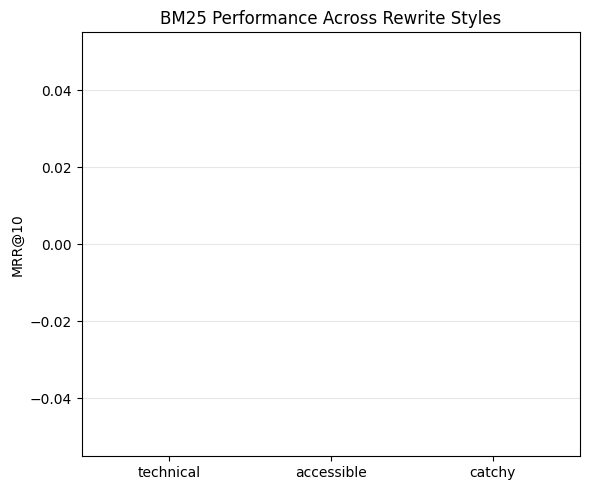

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    style_results["Style"],
    style_results["MRR@10"]
)

plt.ylabel("MRR@10")
plt.title("BM25 Performance Across Rewrite Styles")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/FIFI_Research/figures/Figure13_BM25_Style_Performance.png",
    dpi=300
)

plt.show()

In [ ]:
train_titles = set(train_df["original_title"])

val_titles = set(val_df["original_title"])

print("Train Titles :", len(train_titles))
print("Validation Titles :", len(val_titles))

print("Common Titles :", len(train_titles.intersection(val_titles)))

print("Validation Titles NOT in Train :",
      len(val_titles - train_titles))

Train Titles : 9999
Validation Titles : 2000
Common Titles : 0
Validation Titles NOT in Train : 2000
